<a href="https://colab.research.google.com/github/codemaster-omvardhan/ML-projects/blob/main/LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [4]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [7]:
df = df[df['species']!='setosa']

In [8]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor
53,5.5,2.3,4.0,1.3,versicolor
54,6.5,2.8,4.6,1.5,versicolor


In [10]:
df['species'] = df['species'].map({'versicolor':0, 'virginica':1})

In [15]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,0
51,6.4,3.2,4.5,1.5,0
52,6.9,3.1,4.9,1.5,0
53,5.5,2.3,4.0,1.3,0
54,6.5,2.8,4.6,1.5,0


In [40]:
X = df.iloc[:, [2, 3]]   # petal length & width
y = df.iloc[:, -1]

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
import matplotlib.pyplot as plt

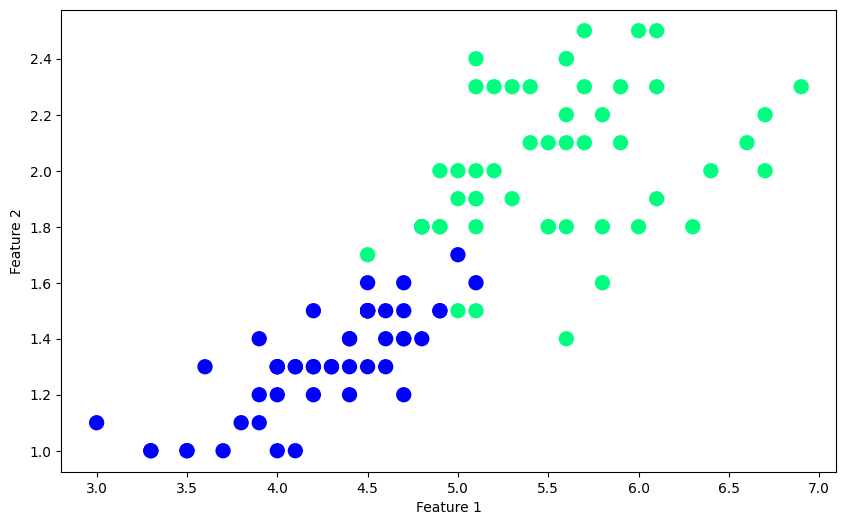

In [44]:
plt.figure(figsize=(10,6))

plt.scatter(
    X.iloc[:, 0],   # feature 1
    X.iloc[:, 1],   # feature 2
    c=y,
    cmap='winter',
    s=100
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [45]:
X_train

,petal_length,petal_width
105,6.6,2.1
138,4.8,1.8
76,4.8,1.4
92,4.0,1.2
119,5.0,1.5
...,...,...
110,5.1,2.0
121,4.9,2.0
64,3.6,1.3
142,5.1,1.9


In [46]:
X_test

,petal_length,petal_width
133,5.1,1.5
103,5.6,1.8
120,5.7,2.3
95,4.2,1.2
94,4.2,1.3
89,4.0,1.3
72,4.9,1.5
130,6.1,1.9
60,3.5,1.0
50,4.7,1.4


In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [48]:
X_train

array([[ 1.95203926,  0.91885246],
       [-0.18881111,  0.20977018],
       [-0.18881111, -0.73567287],
       [-1.14030016, -1.20839439],
       [ 0.04906115, -0.49931211],
       [-0.66455564, -0.73567287],
       [-0.66455564, -1.20839439],
       [ 0.04906115,  0.44613094],
       [-1.2592363 , -0.73567287],
       [ 2.0709754 ,  0.6824917 ],
       [-0.9024279 , -0.49931211],
       [-0.78349177, -0.97203363],
       [ 1.3573586 ,  1.39157398],
       [-0.5456195 , -0.49931211],
       [ 1.11948634,  1.39157398],
       [-0.5456195 , -0.97203363],
       [ 0.64374181,  0.20977018],
       [ 0.40586955,  1.39157398],
       [-0.5456195 , -0.26295135],
       [-0.5456195 , -0.49931211],
       [-1.02136403, -0.97203363],
       [-0.5456195 , -0.49931211],
       [-1.97285309, -1.68111591],
       [ 0.28693342,  1.39157398],
       [ 0.04906115, -0.02659059],
       [-1.2592363 , -1.44475515],
       [ 1.714167  ,  0.6824917 ],
       [-0.66455564, -0.73567287],
       [ 0.64374181,

**Logistic Regression Logic**

In [49]:
import numpy as np

class LogisticRegressionCustom:
    def __init__(self, lr=0.01, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    # Sigmoid function
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    # Training
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)

        n_samples, n_features = X.shape

        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent
        for _ in range(self.n_iters):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)

            # Gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # Update
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    # Prediction
    def predict(self, X):
        X = np.array(X)
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_model)

        # Convert probability → class
        return [1 if i > 0.5 else 0 for i in y_pred]

In [50]:
model = LogisticRegressionCustom(lr=0.01, n_iters=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

# Accuracy
accuracy = np.mean(predictions == y_test)
print("My custom model accuracy is:", accuracy)

My custom model accuracy is: 0.95


**Comparing it with Sklearn Model**

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

sk_model = LogisticRegression()
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)

print("Sklearn Accuracy:", accuracy_score(y_test, sk_pred))


Sklearn Accuracy: 0.9


**Visualizing it in graphs**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


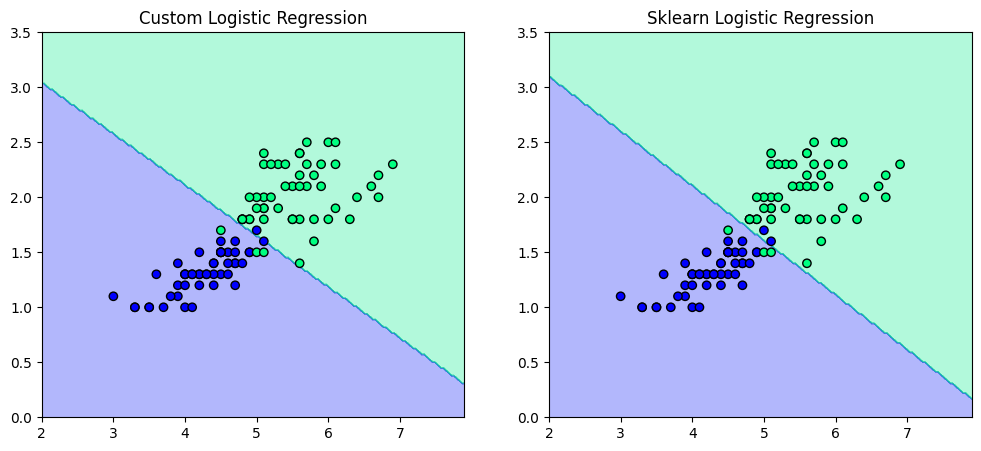

In [55]:

# My model
my_model = LogisticRegressionCustom(lr=0.01, n_iters=1000)
my_model.fit(X_train, y_train)

# sklearn model
from sklearn.linear_model import LogisticRegression
sk_model = LogisticRegression()
sk_model.fit(X_train, y_train)

#Creating Mesh grid
x_min, x_max = X.iloc[:,0].min() - 1, X.iloc[:,0].max() + 1
y_min, y_max = X.iloc[:,1].min() - 1, X.iloc[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid = scaler.transform(grid)

#prediction on grid
Z_custom = np.array(my_model.predict(grid)).reshape(xx.shape)
Z_sklearn = sk_model.predict(grid).reshape(xx.shape)


import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

#My model
plt.subplot(1,2,1)
plt.contourf(xx, yy, Z_custom, alpha=0.3, cmap='winter')
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y, cmap='winter', edgecolors='k')
plt.title("Custom Logistic Regression")

#Sklearn model
plt.subplot(1,2,2)
plt.contourf(xx, yy, Z_sklearn, alpha=0.3, cmap='winter')
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y, cmap='winter', edgecolors='k')
plt.title("Sklearn Logistic Regression")

plt.show()